<img src="https://embit.ru/wp-content/uploads/2023/02/935181-564x150.png" width="1400">

<hr>

# 📚 Содержание

0. [Введение](#section1)  
1. [Импорты](#section2)
2. Цели и задачи исследования  
3. Источники данных  
4. Предобработка данных  
5. Разведочный анализ (EDA)  
6. Построение признаков (Feature Engineering)  
7. Моделирование  
8. Оценка качества модели  
9. Визуализация результатов  
10. Выводы и дальнейшие шаги


<a id="section2"></a>
<h2>Введение: что такое GPS и зачем он нужен?</h2>

## Импорты и загрузка данных

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm
import pandas as pd
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")
np.random.seed(2025)

DATA_PATH = "gsm.csv"
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {DATA_PATH} with shape {df.shape}")
else:
    raise FileNotFoundError(f"Error: no such file {DATA_PATH}")

covariate_cols = ['sum_time_space_sec_prev', 'sum_time_sec_prev', 'sum_time_otr_sec_prev',
                 'sessions_cnt_day_prev', 'age_years', 'delta_days']
df = df.dropna()
df['T_raw'] = df['T']
df['Y_raw'] = df['Y']

# логарифмируем для моделирования
df['T'] = np.log1p(df['T_raw'])
df['Y'] = np.log1p(df['Y_raw'])

Loaded gsm.csv with shape (524367, 8)


In [5]:
df.head()

,sum_time_space_sec_prev,sum_time_sec_prev,sum_time_otr_sec_prev,sessions_cnt_day_prev,age_years,delta_days,T,Y,T_raw,Y_raw
0,68.0,20900.0,6571.0,9.0,43,76,0.000000,0.0,0.000000,0.0
1,11.0,6623.0,1248.0,12.0,42,1,1.481877,0.0,3.401197,0.0
2,18.0,23633.0,4476.0,23.0,42,1,1.860873,0.0,5.429346,0.0
3,19.0,34858.0,7011.0,20.0,42,1,1.958230,0.0,6.086775,0.0
4,36.0,45125.0,9569.0,11.0,42,1,1.962020,0.0,6.113682,0.0


In [2]:
# ---------------- 1) Модель μ(x) ----------------
model_t = RandomForestRegressor(n_estimators=500, min_samples_leaf=10, random_state=42)
model_t.fit(df[covariate_cols], df['T'])
mu_hat = model_t.predict(df[covariate_cols])

In [3]:
# ---------------- 2) Модель σ²(x) ---------------
resid = df['T'] - mu_hat
var_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=2)
var_model.fit(df[covariate_cols], resid**2)
sigma2_hat = var_model.predict(df[covariate_cols])
sigma2_hat = np.maximum(sigma2_hat, 1e-6)
sigma_hat = np.sqrt(sigma2_hat)

df['mu_hat'] = mu_hat     
df['sigma_hat'] = sigma_hat

T = df['T']

In [6]:
# ---------------- 3) Вычисление GPS ----------------
log_gps_obs = norm.logpdf(T, loc=mu_hat, scale=sigma_hat)
gps_obs = np.exp(log_gps_obs)
df['gps'] = gps_obs
df['log_gps'] = log_gps_obs

print("GPS summary:")
print(df[['T','mu_hat','sigma_hat','gps']].describe())

GPS summary:
                   T         mu_hat      sigma_hat            gps
count  524367.000000  524367.000000  524367.000000  524367.000000
mean        3.302301       3.301453       1.431341       3.673948
std         2.816743       1.949154       0.471552      36.025179
min         0.000000       0.000000       0.001000       0.000000
25%         0.000000       1.770350       1.214114       0.131603
50%         3.526361       3.299659       1.517695       0.201613
75%         5.666427       4.749159       1.790777       0.274064
max        12.639931      10.160525       4.788543     398.942280


In [7]:
# ---------------- 4) Outcome модель ----------------
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
TP = poly.fit_transform(df[['T','gps']])
X_out = sm.add_constant(TP, has_constant='add')
out_model = sm.OLS(df['Y'].values, X_out).fit(cov_type='HC3')
params = np.asarray(out_model.params)

print("\nOutcome model coefficients (polynomial basis):")
feature_names = ['const'] + poly.get_feature_names_out(['T','gps']).tolist()
for name, val in zip(feature_names, params):
    print(f"{name:12s} {val:.6f}")


Outcome model coefficients (polynomial basis):
const        0.309007
T            -0.014469
gps          0.000744
T^2          0.002572
T gps        0.001902
gps^2        -0.000001


In [8]:
# ---------------- 5) Dose-response ----------------
t_grid = np.linspace(df['T'].min(), df['T'].max(), 60)
mu_hat_t = []
n = df.shape[0]
for t_star in t_grid:
    log_gps_tstar = norm.logpdf(np.repeat(t_star, n), loc=mu_hat, scale=sigma_hat)
    gps_tstar = np.exp(log_gps_tstar)
    TP_star = poly.transform(np.column_stack([np.repeat(t_star, n), gps_tstar]))
    X_star = sm.add_constant(TP_star, has_constant='add')
    y_pred_i = X_star.dot(params)
    mu_hat_t.append(np.mean(y_pred_i))
mu_hat_t = np.array(mu_hat_t)

# возвращаем в исходную шкалу Y и T
t_grid_raw = np.expm1(t_grid)
mu_hat_t_raw = np.expm1(mu_hat_t)

In [9]:
from tqdm import tqdm
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm

# ---------------- 6) Bootstrap CI ----------------
def bootstrap_dose_response(df, X_out, poly, mu_hat, sigma_hat, t_grid, B=500, seed=123):
    n = len(df)
    boot_mu = np.zeros((B, len(t_grid)))
    rng = np.random.RandomState(seed)
    

    for b in tqdm(range(B), desc="Bootstrapping", unit="iter"):
        idx = rng.randint(0, n, size=n)
        Xb = X_out[idx, :]
        Yb = df['Y'].values[idx]
        try:
            beta, *_ = np.linalg.lstsq(Xb, Yb, rcond=None)
            for j, t_star in enumerate(t_grid):
                log_gps_tstar = norm.logpdf(np.repeat(t_star, n), loc=mu_hat, scale=sigma_hat)
                gps_tstar = np.exp(log_gps_tstar)
                TP_star = poly.transform(np.column_stack([np.repeat(t_star, n), gps_tstar]))
                Xs = sm.add_constant(TP_star, has_constant='add')
                y_pred = Xs.dot(beta)
                boot_mu[b, j] = np.mean(y_pred)
        except Exception:
            boot_mu[b, :] = np.nan
    
    return boot_mu

# пример вызова
B = 500
print(f"\nRunning bootstrap with B={B}...")
boot_mu = bootstrap_dose_response(df, X_out, poly, mu_hat, sigma_hat, t_grid, B=B, seed=123)
ci_lower = np.expm1(np.nanpercentile(boot_mu, 2.5, axis=0))
ci_upper = np.expm1(np.nanpercentile(boot_mu, 97.5, axis=0))


Running bootstrap with B=500...


Bootstrapping: 100%|██████████| 500/500 [45:26<00:00,  5.45s/iter]


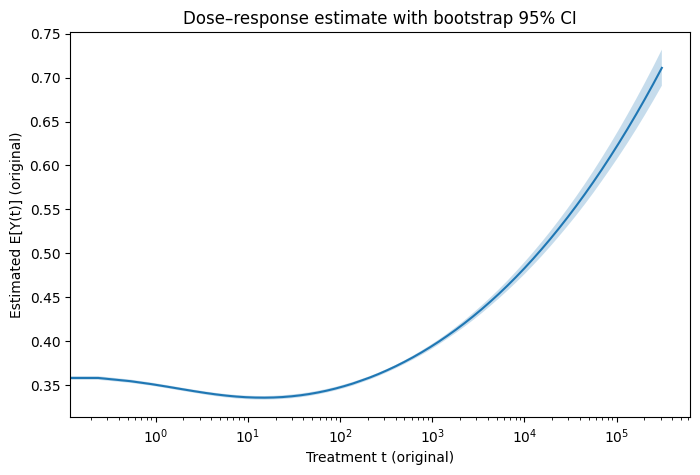

In [10]:
# ---------------- 7) Диагностики ----------------
plt.figure(figsize=(8,5))
plt.plot(t_grid_raw, mu_hat_t_raw)
plt.fill_between(t_grid_raw, ci_lower, ci_upper, alpha=0.25)
plt.xlabel("Treatment t (original)")
plt.xscale('log')
plt.ylabel("Estimated E[Y(t)] (original)")
plt.title("Dose–response estimate with bootstrap 95% CI")
plt.show()


Balance diagnostics (mean and max |SMD| across T bins):
                 covariate  smd_raw_mean  smd_resid_mean  smd_raw_max  \
2    sum_time_otr_sec_prev      0.034798        0.033333     0.713098   
1        sum_time_sec_prev      0.043297        0.041635     0.667394   
0  sum_time_space_sec_prev      0.022653        0.021810     0.454741   
3    sessions_cnt_day_prev      0.030681        0.028163     0.261768   
4                age_years     -0.003918       -0.003235     0.056820   
5               delta_days      0.002056        0.004133     0.023942   

   smd_resid_max  
2       0.706478  
1       0.659973  
0       0.450278  
3       0.251940  
4       0.059422  
5       0.032029  

⚠️ Предупреждение: для следующих ковариат найдены бины с нулевой дисперсией:
['sum_time_space_sec_prev', 'sum_time_sec_prev', 'sum_time_otr_sec_prev', 'sessions_cnt_day_prev', 'age_years', 'delta_days']


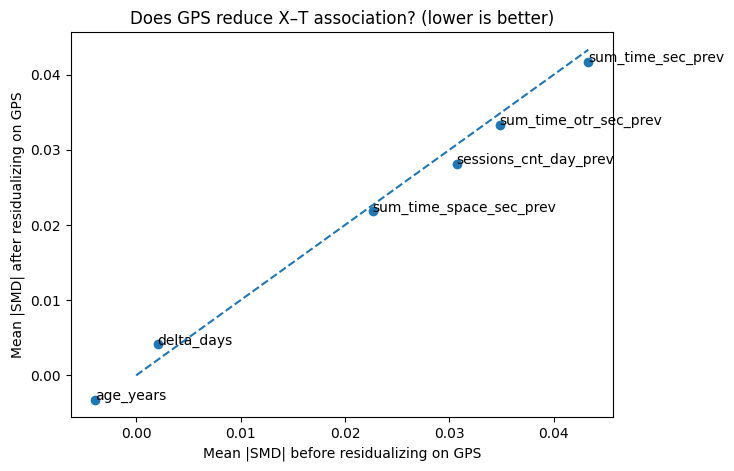

In [11]:
# ---------------- 8) Баланс после GPS ----------------
from sklearn.linear_model import LinearRegression

n_bins = 5
df['t_bin'] = pd.qcut(df['T'], q=n_bins, labels=False, duplicates="drop")

def smd(a, b):
    ma, mb = a.mean(), b.mean()
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt((sa**2 + sb**2)/2.0)
    if pooled < 1e-8:   # защита от деления на ноль
        return np.nan
    return (ma - mb) / pooled

smd_rows = []
problematic = []

for col in covariate_cols:
    cov = df[col].values
    GM = LinearRegression().fit(df[['gps']], cov.reshape(-1,1))
    cov_pred = GM.predict(df[['gps']]).ravel()
    cov_resid = cov - cov_pred
    
    raw_list, resid_list = [], []
    for b in range(n_bins):
        mask_bin = df['t_bin']==b
        mask_rest = ~mask_bin
        smd_raw = smd(cov[mask_bin], cov[mask_rest])
        smd_res = smd(cov_resid[mask_bin], cov_resid[mask_rest])
        raw_list.append(smd_raw)
        resid_list.append(smd_res)
    
    # если NaN → значит в каком-то бине константа
    if np.any(np.isnan(raw_list)) or np.any(np.isnan(resid_list)):
        problematic.append(col)
    
    smd_rows.append({
        "covariate": col,
        "smd_raw_mean": np.nanmean(raw_list),
        "smd_resid_mean": np.nanmean(resid_list),
        "smd_raw_max": np.nanmax(raw_list),
        "smd_resid_max": np.nanmax(resid_list)
    })

smd_df = pd.DataFrame(smd_rows).sort_values('smd_raw_max', ascending=False)
print("\nBalance diagnostics (mean and max |SMD| across T bins):")
print(smd_df)

if problematic:
    print("\n⚠️ Предупреждение: для следующих ковариат найдены бины с нулевой дисперсией:")
    print(problematic)

plt.figure(figsize=(7,5))
plt.scatter(smd_df['smd_raw_mean'], smd_df['smd_resid_mean'])
for _, r in smd_df.iterrows():
    plt.text(r['smd_raw_mean'], r['smd_resid_mean'], r['covariate'])
plt.plot([0, max(smd_df['smd_raw_mean'].max(), smd_df['smd_resid_mean'].max())],
         [0, max(smd_df['smd_raw_mean'].max(), smd_df['smd_resid_mean'].max())], linestyle='--')
plt.xlabel("Mean |SMD| before residualizing on GPS")
plt.ylabel("Mean |SMD| after residualizing on GPS")
plt.title("Does GPS reduce X–T association? (lower is better)")
plt.show()


In [12]:
# ---------------- 9) Эффекты ----------------
t_min_idx = np.argmin(mu_hat_t_raw)
t_max_idx = np.argmax(mu_hat_t_raw)
t_min, mu_min = t_grid_raw[t_min_idx], mu_hat_t_raw[t_min_idx]
t_max, mu_max = t_grid_raw[t_max_idx], mu_hat_t_raw[t_max_idx]

abs_increase = mu_max - mu_min
rel_increase = abs_increase / mu_min

print(f"Минимум: mu({t_min:.2f}) = {mu_min:.3f}")
print(f"Максимум: mu({t_max:.2f}) = {mu_max:.3f}")
print(f"Абсолютный прирост: {abs_increase:.3f}")
print(f"Относительный прирост: {rel_increase:.1%}")

Минимум: mu(15.20) = 0.336
Максимум: mu(308639.00) = 0.711
Абсолютный прирост: 0.375
Относительный прирост: 111.8%


<img src='treat.png'>

### Считаем какой эффект мы оказались на Retention Rate 4 Weak

In [13]:
from scipy.interpolate import interp1d

# создаём интерполятор для кривой, чтобы найти новые значения на кривой
interp_mu = interp1d(t_grid_raw, mu_hat_t_raw, kind="linear", fill_value="extrapolate")

# точки
t0, t1 = 90, 120
mu0, mu1 = interp_mu(t0), interp_mu(t1)

# приросты
abs_increase = mu1 - mu0
rel_increase = abs_increase / mu0 * 100

print(f"При {t0:.0f} сек RR4W = {mu0:.3f}")
print(f"При {t1:.0f} сек RR4W = {mu1:.3f}")
print(f"Абсолютный прирост = {abs_increase:.3f}")
print(f"Относительный прирост = {rel_increase:.1f}%")


При 90 сек RR4W = 0.346
При 120 сек RR4W = 0.350
Абсолютный прирост = 0.004
Относительный прирост = 1.1%
